# Redshift DataSet Regressor: Linear Regression

## import libraries

In [1]:
# arrays
import numpy as np

# unpacking files
import tarfile

# fits
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.table import Table
import pandas as pd

# plotting
from matplotlib import pyplot as plt

# sklearn 
from sklearn.model_selection import train_test_split #, RandomizedSearchCV, validation_curve
#from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Read and Inspect Data

In [2]:
file_url = 'https://archive.stsci.edu/missions/hlsp/3d-hst/RELEASE_V4.0/Photometry/3dhst_master.phot.v4.1.tar'
tarfile.open(download_file(file_url, cache=True), "r:").extract('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', '.')
tab = Table.read('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', format='ascii').to_pandas()
tab.head()

,id,field,ra,dec,x,y,z_spec,z_peak,faper_F140W,eaper_F140W,...,flags,f140w_flag,star_flag,use_phot,near_star,nexp_f125w,nexp_f140w,nexp_f160w,lmass,Av
0,1.0,AEGIS,215.222382,53.004185,9590.5,3057.3,-1.0,0.0100,-82.0410,-82.041000,...,0,0,1,0,0,2,0,3,7.51,1.1
1,2.0,AEGIS,215.096588,52.918053,16473.2,3150.2,-1.0,0.0100,3.5078,0.074233,...,3,0,0,0,0,4,4,4,5.62,0.1
2,3.0,AEGIS,215.161469,52.959461,13060.1,2982.3,-1.0,0.2062,-1.9043,-1.904300,...,1,0,0,1,0,2,0,2,9.00,1.1
3,4.0,AEGIS,215.305298,53.052921,5422.8,2692.1,-1.0,0.0355,-72.3250,-72.325000,...,0,0,0,0,0,1,0,1,4.78,0.4
4,5.0,AEGIS,215.041840,52.871273,19894.6,2834.4,-1.0,0.3427,1890.5000,0.133300,...,0,1,2,0,1,0,3,0,11.57,0.5


In [3]:
tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207967 entries, 0 to 207966
Data columns (total 38 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           207967 non-null  float64
 1   field        207967 non-null  object 
 2   ra           207967 non-null  float64
 3   dec          207967 non-null  float64
 4   x            207967 non-null  float64
 5   y            207967 non-null  float64
 6   z_spec       207967 non-null  float64
 7   z_peak       207967 non-null  float64
 8   faper_F140W  207967 non-null  float64
 9   eaper_F140W  207967 non-null  float64
 10  faper_F160W  207967 non-null  float64
 11  eaper_F160W  207967 non-null  float64
 12  f_F606W      207967 non-null  float64
 13  e_F606W      207967 non-null  float64
 14  f_F814W      207967 non-null  float64
 15  e_F814W      207967 non-null  float64
 16  f_F125W      207967 non-null  float64
 17  e_F125W      207967 non-null  float64
 18  f_F140W      207967 non-

## Clean up 

Before building and applying a regression model, we first need to inspect and clean the dataset.

To explore the physical parameters of the sample, we plot the spectroscopic redshift vs. the mass derived from the FAST phototmetric fit:

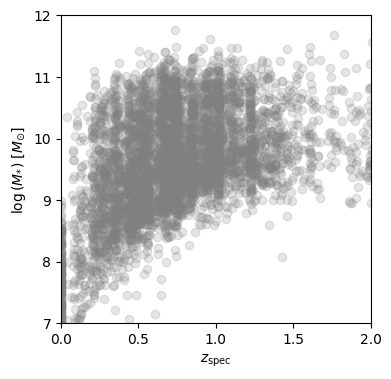

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(tab.z_spec, tab.lmass, alpha=0.2, color='grey')
ax.set_xlim(0, 2)
ax.set_ylim(7, 12)
ax.set_xlabel(r'$z_{\rm spec}$')
ax.set_ylabel(r'$\log{(M_{*})}\,\,[M_{\odot}]$')

plt.show()

By inspection of this plot, we will only keep sources with log(M)>9 to remove sources which do not have complete coverage across redshift.

In [5]:
print('number of datapoints originally = {}'.format(tab.shape[0]))
tab = tab[tab.lmass > 9].copy()
print('number of datapoints after drop = {}'.format(tab.shape[0]))

number of datapoints originally = 207967
number of datapoints after drop = 63390


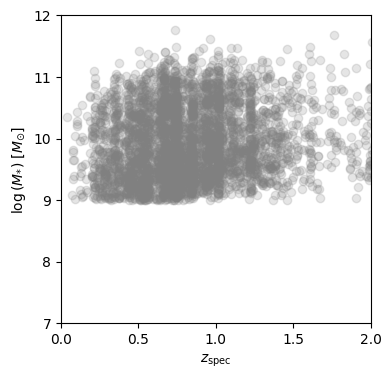

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(tab.z_spec, tab.lmass, alpha=0.2, color='grey')
ax.set_xlim(0, 2)
ax.set_ylim(7, 12)
ax.set_xlabel(r'$z_{\rm spec}$')
ax.set_ylabel(r'$\log{(M_{*})}\,\,[M_{\odot}]$')

plt.show()

We're interested in predicting redshift, so our "target" variable will be z_spec. The "features" will be all columns except for the spectroscopic and photometric redshifts.

In [7]:
target = 'z_spec'
features = [col for col in tab.columns if (col != target)]

Let's drop a few of the features. The 'Av', 'lmass' and 'z_peak' values were all computed via FAST photometric fit, and so we will exclude them as well. In addition, we will exclude the categorical flag variables ('flags', 'f140w_flag', 'star_flag', 'use_phot', 'near_star').

In [8]:
features = [col for col in features if (col != 'Av') and (col != 'lmass') and (col != 'z_peak') 
            and (col != 'flags') and (col != 'f140w_flag') and (col != 'star_flag') 
            and (col != 'use_phot') and (col != 'near_star')]
features

['id',
 'field',
 'ra',
 'dec',
 'x',
 'y',
 'faper_F140W',
 'eaper_F140W',
 'faper_F160W',
 'eaper_F160W',
 'f_F606W',
 'e_F606W',
 'f_F814W',
 'e_F814W',
 'f_F125W',
 'e_F125W',
 'f_F140W',
 'e_F140W',
 'f_F160W',
 'e_F160W',
 'tot_cor',
 'kron_radius',
 'a_image',
 'b_image',
 'flux_radius',
 'fwhm_image',
 'nexp_f125w',
 'nexp_f140w',
 'nexp_f160w']

Next, we will remove sources which have no constraints for our target variable:

In [9]:
print('number of datapoints originally = {}'.format(tab.shape[0]))
tab = tab[(tab[target] > 0)] 
print('number of datapoints after drop = {}'.format(tab.shape[0]))

number of datapoints originally = 63390
number of datapoints after drop = 4173


Categorical variables need to be modified to become numerical values. We can do this using sklearn's LabelEncoder.

In [10]:
label_encoder = LabelEncoder()
tab['field'] = label_encoder.fit_transform(tab['field'])

Finally we will impute missing values of photometric errors (set to -99. in the table) by assigning them the median of the distribution:

In [11]:
# get columns associated with errors
errors = [col for col in features if (col[:1] == 'e') and (col[-1:] == 'W')]
errors

['eaper_F140W',
 'eaper_F160W',
 'e_F606W',
 'e_F814W',
 'e_F125W',
 'e_F140W',
 'e_F160W']

In [12]:
# impute values with median
for error in errors:
    tab[error] = np.where(tab[error] < -90, tab[error].median(), tab[error])

Finally lets inspect distribution of features

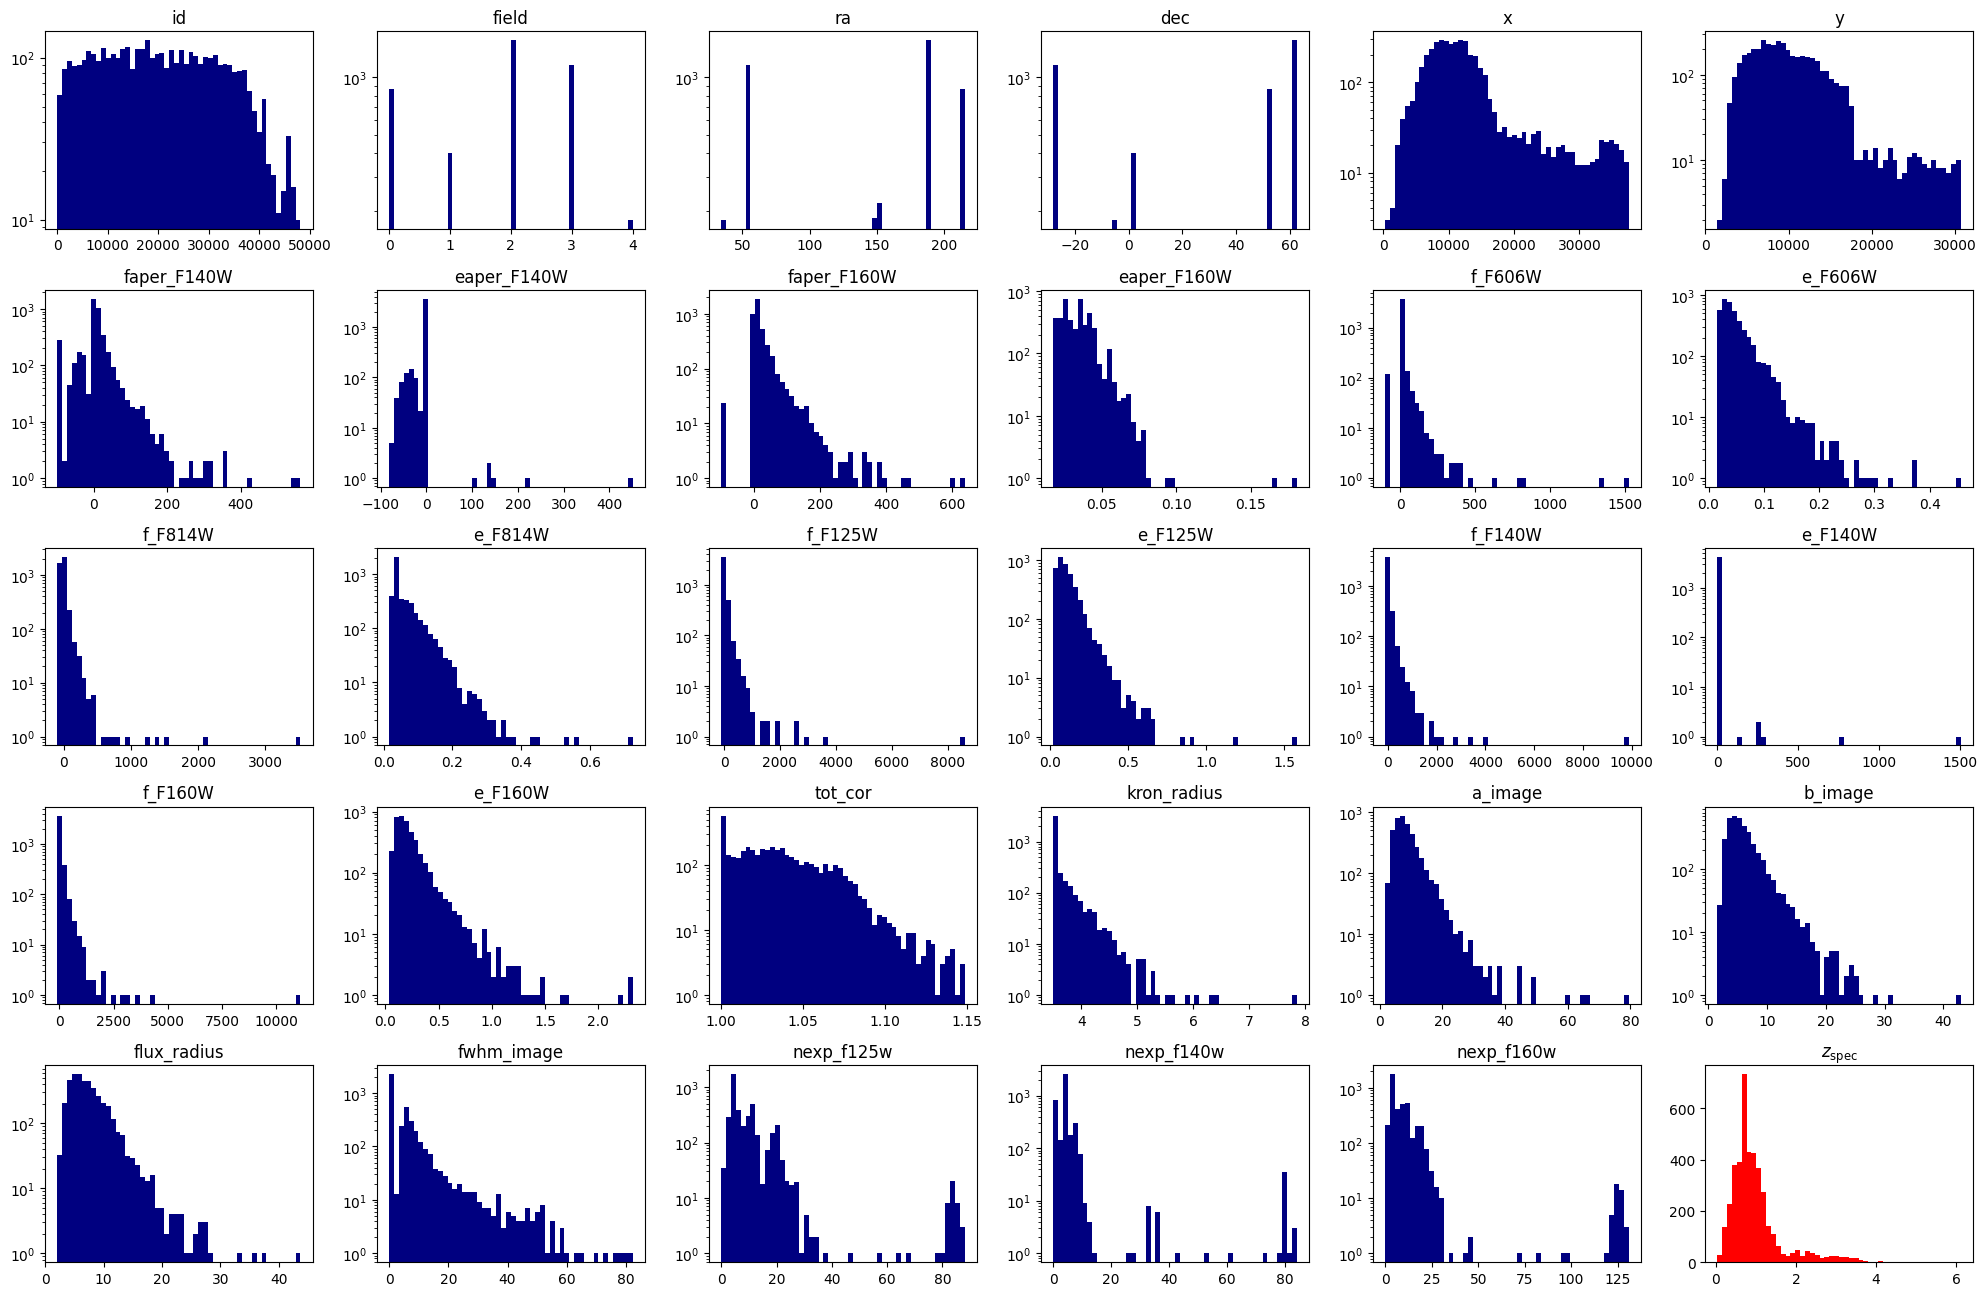

In [13]:
fig = plt.figure(0, [20, 18])

for k, feat in enumerate(features):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(tab[feat], bins=50, log=True, color='navy')
    ax.set_title(feat)

ax = fig.add_subplot(7, 6, len(features)+1)
ax.hist(tab[target], bins=50, color='red')
ax.set_title(r'$z_{\rm spec}$')

plt.tight_layout()
plt.show()

## Build and Evaluate Baseline Models 

When building machine learning models its good to start with a baseline model.  This will give you a place to reference back to in terms of the evaluation metrics you are computing. In this notebook, we will start with a few simple things just to get a feel of what performance we can expect from our models:

1. **Mean Regressor:** we predict our target is the mean of all the target values contained in our dataset
2. Multiple Linear regression with no feature engineering


### Test / Train Split 

Let's get started by splitting the data we have into three groups:

1. Training: Data used to train the model
2. Testing: Data used to evaluate models performance when performing model tuning
3. Validation: Data used to evaluate the models performance on unseen data points 

In [14]:
# Define X (features ) and y (target) for the dataset we are using
X = tab[features]
y = tab[target]

# first reserve 70% of the data for training, 30% for validation
X_train, X_validate, y_train, y_validate= train_test_split(X, y,  
                                                           test_size=0.3, 
                                                           random_state=42)

# second, split the validation set in half to obtain validation and test sets. 
X_validate, X_test, y_validate, y_test = train_test_split(X_validate, 
                                                          y_validate,  
                                                          test_size=0.5, 
                                                          random_state=42)

### Mean Regressor 

Next, lets build out mean regressor.  This can be done using sklearn's `DummyRegressor` class. 

In [15]:
from sklearn.dummy import DummyRegressor
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)

dummy_regr.predict(X_test)[0:10]

array([1.00031236, 1.00031236, 1.00031236, 1.00031236, 1.00031236,
       1.00031236, 1.00031236, 1.00031236, 1.00031236, 1.00031236])

In [16]:
# evaluate model 
y_predict = dummy_regr.predict(X_test) # get predictions
mse_dummy_regr= mean_squared_error(y_test, y_predict )
print('Mean squared error for mean regressor baseline: {}'.format(mse_dummy_regr))

Mean squared error for mean regressor baseline: 0.44378618168122164


## Naive Multiple Linear Regression with no feature engineering / inspection

Another thing we can do is just try multiple linear regression with our data.  I wouldn't expect good results here, but by comparing the results of this with the mean regressor will give us a sense for if there is signal in our data as the features currently are for linear regression.  

When building linear regression models, we have a choice of whether we standardize our data.  There are pros to either decision:

1. **Standardize data:** All of our features are on the same scale which means we can compare our learned coefficients.  This could give us insight into which of our features are the most helpful for making predictions.  However, we can interpret slopes 
2. **Do not standardize data:** We maintain the interpretation of coefficients

I would like to use this initial pass to gain some instinct for what features are most important, so I will standardize our data and then compare the coefficients. 

In [17]:
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg = LinearRegression().fit(X_train_scaled, y_train)

# evaluate model 
y_predict = linreg.predict(X_test_scaled) # get predictions
mse_mlr=mean_squared_error(y_test, y_predict )
print('Mean squared error for multiple linear regression baseline: {}'.format(mse_mlr))

Mean squared error for multiple linear regression baseline: 0.2710123620157967


Since we standardized our data we can compare the coefficients to see what feature is playing the biggest role in making predictions. Below I place the coefficients in to a dataframe.

In [18]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': linreg.coef_, 'importance':np.absolute(linreg.coef_)})
coef_df.sort_values(by='importance',ascending=False)

,Feature,Coefficient,importance
14,f_F125W,-0.909932,0.909932
18,f_F160W,0.864474,0.864474
20,tot_cor,0.385636,0.385636
2,ra,0.278034,0.278034
1,field,0.236079,0.236079
21,kron_radius,0.152935,0.152935
3,dec,-0.152908,0.152908
9,eaper_F160W,-0.105893,0.105893
24,flux_radius,0.091655,0.091655
19,e_F160W,0.081013,0.081013


Now, lets take the information above and see if we can use it to dive deeper into a few features

## Simple Linear Regression with Feature Engineering

Let's explore some of our top performing feature based on analysis above: f_F125W. First let's just see what the relationship looks like between feature and target.  

**Exercise**: Try uncommenting log scales and see what you discover.

Text(0, 0.5, 'z spec')

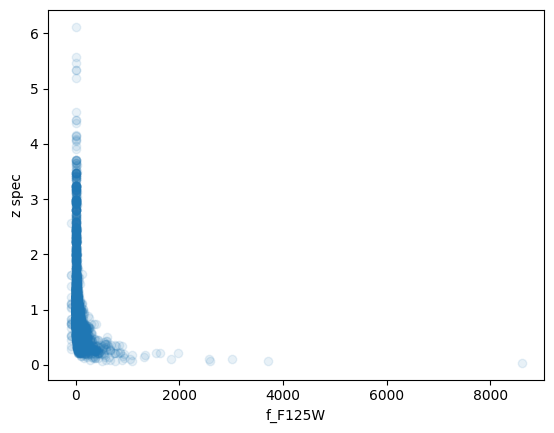

In [19]:
fig, ax = plt.subplots()
ax.scatter(tab.f_F125W,tab.z_spec,alpha=0.1)
ax.set_xlabel('f_F125W')
ax.set_ylabel('z spec')

################################
# Uncomment lines to see how plot changes 
################################
#ax.set_yscale('log')
#ax.set_xscale('log')

Based on data visualization above, lets engineer some new features and see what kind of performance that will give use.  In this example we will, take the log of both the feature and target.

Text(0, 0.5, 'log(z spec)')

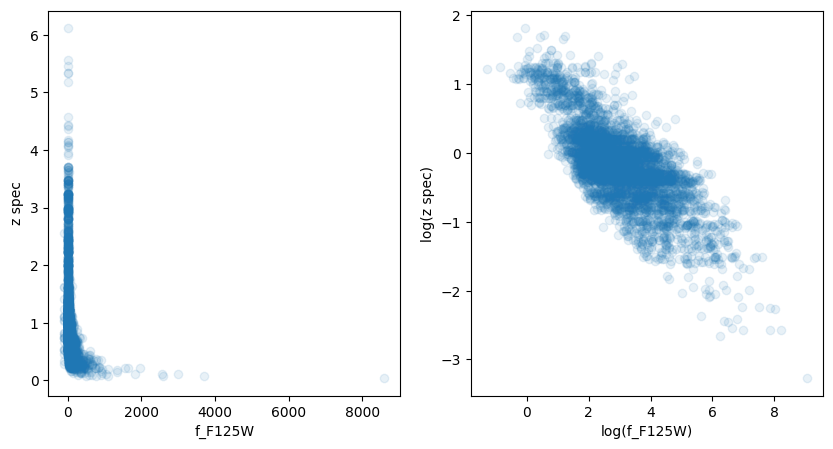

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].scatter(tab.f_F125W,tab.z_spec,alpha=0.1)
ax[1].scatter(np.log(tab.f_F125W),np.log(tab.z_spec),alpha=0.1)
ax[0].set_xlabel('f_F125W')
ax[0].set_ylabel('z spec')
ax[1].set_xlabel('log(f_F125W)')
ax[1].set_ylabel('log(z spec)')
#ax = scatter_matrix(tab[['f_F140W','f_F606W', 'z_spec']], ax=ax) #, diagonal='kde')

Before we engineer this new feature, we will want to make sure there are no negative values in the 'f_F125W' column.

In [21]:
# when taking logs its important to ensure no negative values.  Lets see how many negative values we have
(tab[['f_F125W']] < 0).value_counts()

f_F125W
False      4149
True         24
Name: count, dtype: int64

Since its a small fraction of the data, lets drop these values

In [22]:
tab = tab[tab['f_F125W'] > 0]

Now lets build a a few models with simple linear regression where we engineer our feature and target; in this example we take the log of both the feature and target


In [23]:
# Do Another test train split with only the f_F125W column
X_train, X_test, y_train, y_test = train_test_split(tab[['f_F125W']], 
                                                    tab.z_spec,
                                                    random_state = 0)

simplelinreg_log = LinearRegression().fit(np.log(X_train), np.log(y_train))

Next lets evaluate our model.  It is important to note that if we are predicting the log(z_spec) with our linear regression model, we will need to convert the models prediction back to z_spec by using `np.exp()`. 

In [24]:
# evaluate linreg_log model 
y_predict = np.exp(simplelinreg_log.predict(np.log(X_test))) # get note, we undo the log of the target by using np.exp
mse_linreg_log = mean_squared_error(y_test, y_predict )

# compare performance of our simple linear regression models with our baselines
print('Mean squared error for mean regressor baseline: {}'.format(mse_dummy_regr))
print('Mean squared error for multiple linear regression baseline: {}'.format(mse_mlr))
print('The MSE for linreg is {}'.format(mse_linreg_log))

Mean squared error for mean regressor baseline: 0.44378618168122164
Mean squared error for multiple linear regression baseline: 0.2710123620157967
The MSE for linreg is 0.20163399024493806


OK, nice! using simple linear regression with engineering features, we have a better score than our initial pass with MLR.  

Next, we will visualize our models prediction against the data below.

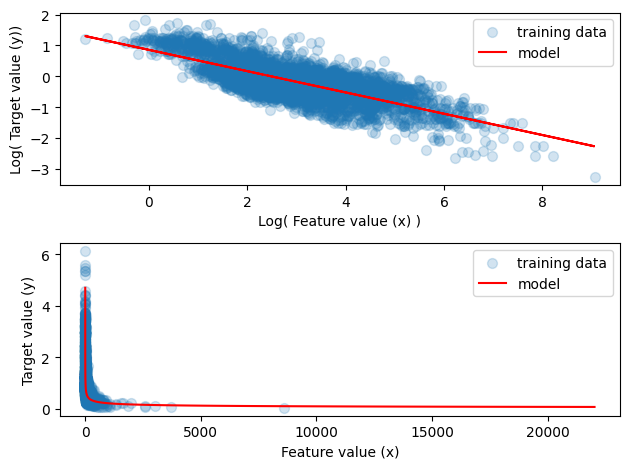

In [25]:
fig,ax = plt.subplots(2)

logx = np.log(tab[['f_F125W']])
logy= np.log(tab.z_spec)
ax[0].scatter(logx, logy, marker= 'o', s=50, alpha=0.2, label='training data')
ax[0].plot(logx, simplelinreg_log.coef_ * logx+ simplelinreg_log.intercept_, 'r-', label='model')
#ax[0].set_title('Least-squares linear regression')
ax[0].set_xlabel('Log( Feature value (x) )')
ax[0].set_ylabel('Log( Target value (y))')
ax[0].legend()

# values for drawing line
x = np.linspace(-2,10,100)
y_predictions = np.exp( simplelinreg_log.coef_ * x+ simplelinreg_log.intercept_ )

ax[1].scatter(tab.f_F125W, tab.z_spec, marker= 'o', s=50, alpha=0.2, label='training data')
ax[1].plot(np.exp(x), y_predictions, 'r-', label='model')
#ax[1].set_title('Least-squares linear regression')
ax[1].set_xlabel('Feature value (x)')
ax[1].set_ylabel('Target value (y)')
ax[1].legend()

fig.tight_layout()

## Try using MLR with a  adding a few more features and/ or using regularized regression 

First we will copy our dataframe for future feature engineering and pull out features based on the initial linear regres

['field', 'ra', 'dec', 'eaper_F160W', 'f_F125W', 'f_F160W', 'tot_cor', 'kron_radius']


array([[<Axes: xlabel='field', ylabel='field'>,
        <Axes: xlabel='ra', ylabel='field'>,
        <Axes: xlabel='dec', ylabel='field'>,
        <Axes: xlabel='eaper_F160W', ylabel='field'>,
        <Axes: xlabel='f_F125W', ylabel='field'>,
        <Axes: xlabel='f_F160W', ylabel='field'>,
        <Axes: xlabel='tot_cor', ylabel='field'>,
        <Axes: xlabel='kron_radius', ylabel='field'>,
        <Axes: xlabel='z_spec', ylabel='field'>],
       [<Axes: xlabel='field', ylabel='ra'>,
        <Axes: xlabel='ra', ylabel='ra'>,
        <Axes: xlabel='dec', ylabel='ra'>,
        <Axes: xlabel='eaper_F160W', ylabel='ra'>,
        <Axes: xlabel='f_F125W', ylabel='ra'>,
        <Axes: xlabel='f_F160W', ylabel='ra'>,
        <Axes: xlabel='tot_cor', ylabel='ra'>,
        <Axes: xlabel='kron_radius', ylabel='ra'>,
        <Axes: xlabel='z_spec', ylabel='ra'>],
       [<Axes: xlabel='field', ylabel='dec'>,
        <Axes: xlabel='ra', ylabel='dec'>,
        <Axes: xlabel='dec', ylabel='dec'>,


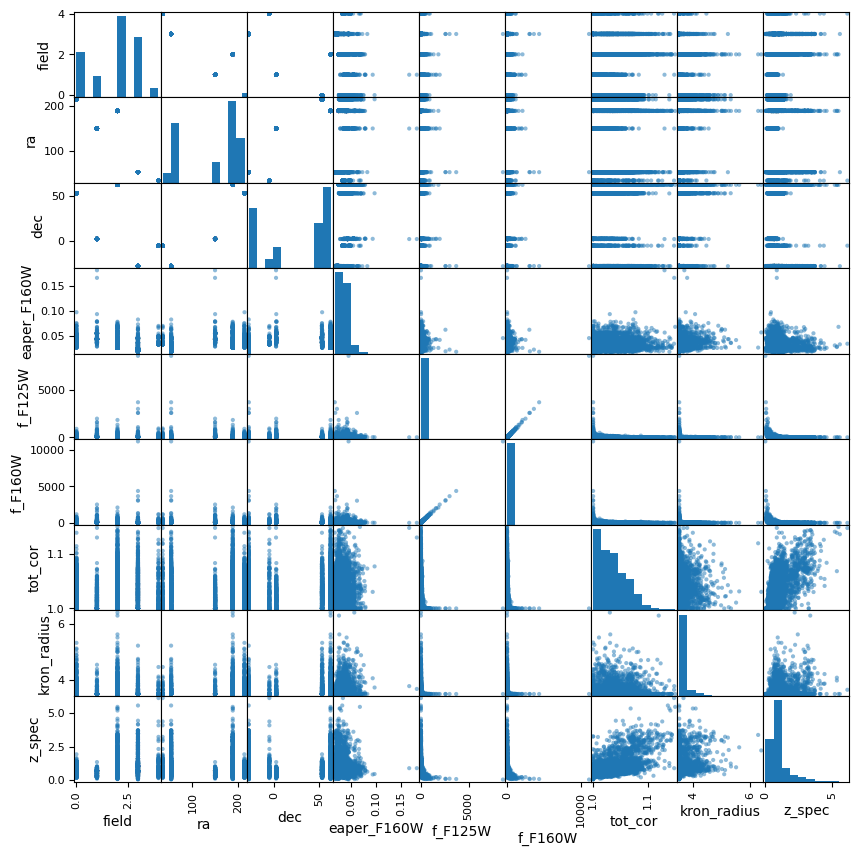

In [26]:
# copy dataframe 
tab_engineer = tab.copy()

# pull out feature list for coefficients of linear regression model; pick any coefficient larger than 0.1
new_features=coef_df[coef_df.importance > 0.1].Feature.to_list()
print(new_features)
pd.plotting.scatter_matrix(tab_engineer[new_features+[target]],figsize=(10,10))

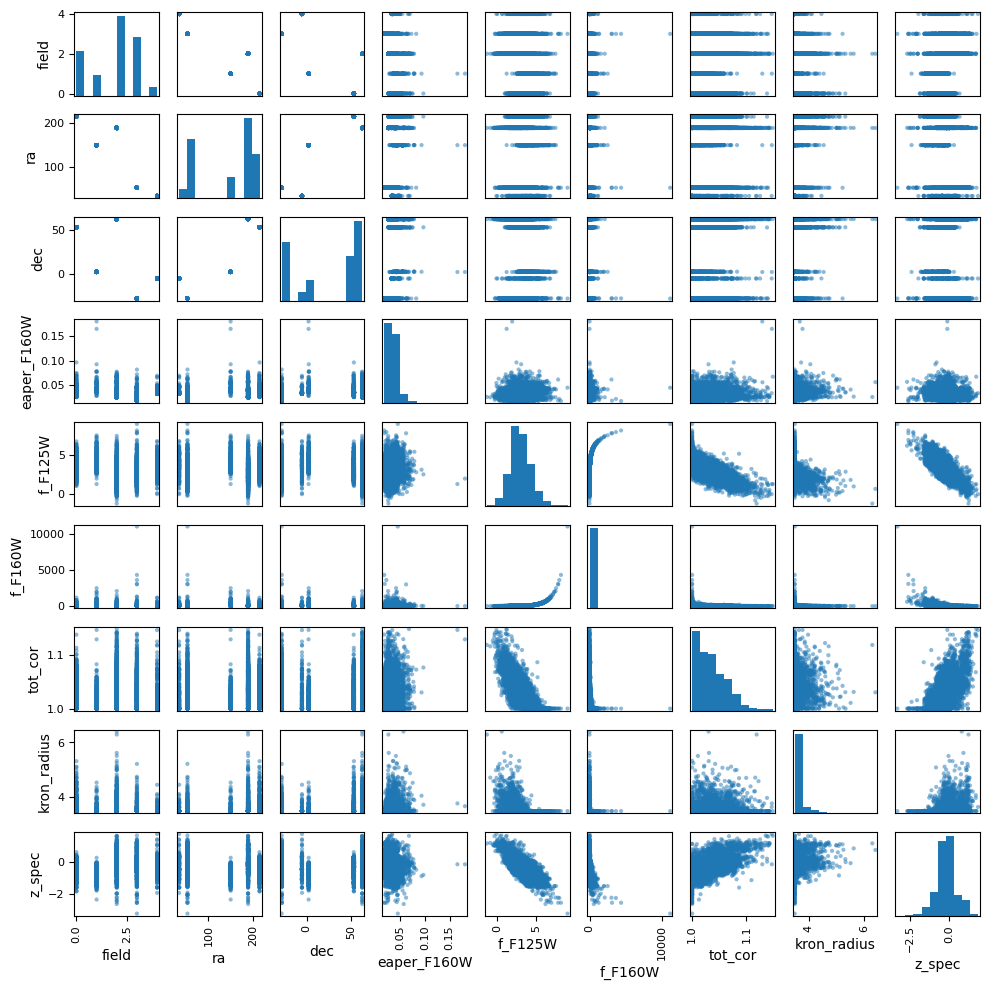

In [27]:
# remove f_160W because they are highly colinear
if 'f_F160W' in new_features:
    new_features.remove('f_F160W')

# engineer new features from simple linear regression example 
tab_engineer = tab.copy()
tab_engineer[target] = np.log(tab_engineer[target])
tab_engineer['f_F125W'] = np.log(tab_engineer['f_F125W'])

# plot new scatter matrix
pd.plotting.scatter_matrix(tab_engineer[new_features+[target]],figsize=(10,10))
plt.tight_layout();

Now lets use our new feature list and see if we get any performance improvement for our linear regression model with additional features.

In [28]:
X = tab_engineer[new_features]
y = tab_engineer[target]

# first reserve 70% of the data for training, 30% for validation
X_train, X_validate, y_train, y_validate= train_test_split(X, y,test_size=0.3, random_state=42)

# second, split the validation set in half to obtain validation and test sets. 
X_validate, X_test, y_validate, y_test = train_test_split(X_validate, y_validate, test_size=0.5, random_state=42)

# Scale data so we can compare slopes 
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg_eng = LinearRegression().fit(X_train_scaled, y_train)

# evaluate model 
y_predict = np.exp(linreg_eng.predict(X_test_scaled))# get predictions
mse_mlr_eng=mean_squared_error(np.exp(y_test), y_predict )
print('Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: {}'.format(mse_mlr_eng))

Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: 0.18021833095409137


In [29]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': linreg_eng.coef_, 'importance':np.absolute(linreg_eng.coef_)})
coef_df.sort_values(by='importance',ascending=False)

,Feature,Coefficient,importance
4,f_F125W,-0.402419,0.402419
1,ra,-0.076196,0.076196
2,dec,0.073462,0.073462
0,field,0.035031,0.035031
6,tot_cor,0.032364,0.032364
5,f_F160W,-0.021704,0.021704
3,eaper_F160W,-0.018621,0.018621
7,kron_radius,0.008236,0.008236


Finally, let's see if we use some regularization techniques if that improves performance of our model

In [30]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn import preprocessing

def evaluate(model,X_test_scaled,y_test):
    y_predict = np.exp(model.predict(X_test_scaled)) # get predictions and undo log of target
    return mean_squared_error(np.exp(y_test), y_predict ) # compute MSE

alphas = np.logspace(-7, 7, 11)
models_lasso={}
models_ridge={}
for alpha in alphas:
    # build model
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train_scaled, y_train)
    models_lasso[alpha]=model

    # build model
    modelr = Ridge(alpha=alpha, max_iter=1000000)
    modelr.fit(X_train_scaled, y_train)
    models_ridge[alpha]=modelr

In [31]:
# evaluate models 
mse_array_lasso = [evaluate(model,X_test_scaled,y_test) for model in models_lasso.values()]
mse_array_ridge = [evaluate(model,X_test_scaled,y_test) for model in models_ridge.values()]

Best score from Ridge Regression 0.1802183309542157
Best score from Lasso Regression 0.1802183336671103


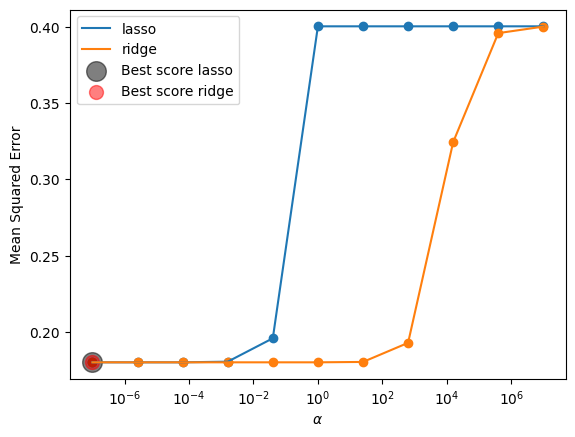

In [32]:
fig,ax=plt.subplots()
ax.plot(alphas,mse_array_lasso,label='lasso')
ax.scatter(alphas,mse_array_lasso)

ax.plot(alphas,mse_array_ridge,label='ridge')
ax.scatter(alphas,mse_array_ridge)

ax.scatter(alphas[np.argmin(mse_array_lasso)],np.array(mse_array_lasso).min(), c='k', s=200,alpha=0.5,label='Best score lasso')
ax.scatter(alphas[np.argmin(mse_array_ridge)],np.array(mse_array_ridge).min(), c='r', s=100,alpha=0.5,label='Best score ridge')

ax.legend()
ax.set_xscale('log')
ax.set_ylabel('Mean Squared Error')
ax.set_xlabel("$\\alpha$")

print("Best score from Ridge Regression {}".format(mse_array_ridge[np.argmin(mse_array_ridge)]))
print("Best score from Lasso Regression {}".format(mse_array_lasso[np.argmin(mse_array_lasso)]))

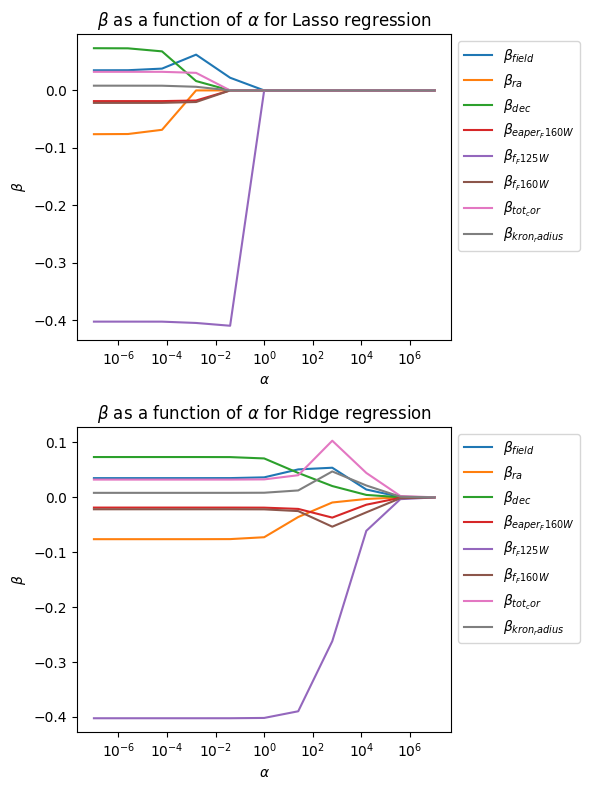

In [33]:
def plot_alpha_v_coef(ax, alphas, coefs, column_names, method='Lasso'):
    '''
    plots alpha versus the beta coefficients 
    '''
    for feature in range(len(coefs[0])):
            ax.plot(alphas, coefs[:, feature],
                     label="$\\beta_{{{}}}$".format(column_names[feature]))  #'{} order'.format(feature+1))
    ax.set_xscale('log')
    ax.set_title("$\\beta$ as a function of $\\alpha$ for {} regression".format(method))
    ax.set_xlabel("$\\alpha$")
    ax.set_ylabel("$\\beta$")
    ax.legend(loc="upper left",bbox_to_anchor=(1,1))

# get coef matrix
coefs_lasso = np.zeros((len(alphas), len(X.columns)))
for i,model in enumerate(models_lasso.values()):
    coefs_lasso[i] = model.coef_
coefs_ridge = np.zeros((len(alphas), len(X.columns)))
for i,model in enumerate(models_ridge.values()):
    coefs_ridge[i] = model.coef_

fig,ax=plt.subplots(2,figsize=(6,8))
plot_alpha_v_coef(ax[0], alphas, coefs_lasso, X.columns, method='Lasso')
plot_alpha_v_coef(ax[1], alphas, coefs_ridge, X.columns, method='Ridge')
fig.tight_layout()

In [34]:
print('Mean squared error for mean regressor baseline: {}'.format(mse_dummy_regr))
print('Mean squared error for multiple linear regression baseline: {}'.format(mse_mlr))
print('The MSE for linreg is {}'.format(mse_linreg_log))
print('Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: {}'.format(mse_mlr_eng))
print("Best score from Ridge Regression {}".format(mse_array_ridge[np.argmin(mse_array_ridge)]))

Mean squared error for mean regressor baseline: 0.44378618168122164
Mean squared error for multiple linear regression baseline: 0.2710123620157967
The MSE for linreg is 0.20163399024493806
Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: 0.18021833095409137
Best score from Ridge Regression 0.1802183309542157


In [35]:
# compare error to z_peak and see how far we have to go 
print("Best score from Astronomy Paper {}".format(mean_squared_error(tab.loc[X_test.index].z_spec,tab.loc[X_test.index].z_peak)))

Best score from Astronomy Paper 0.09328010422150884


**Exercise:** Can you do better than what we have done so far by engineering new features? 
